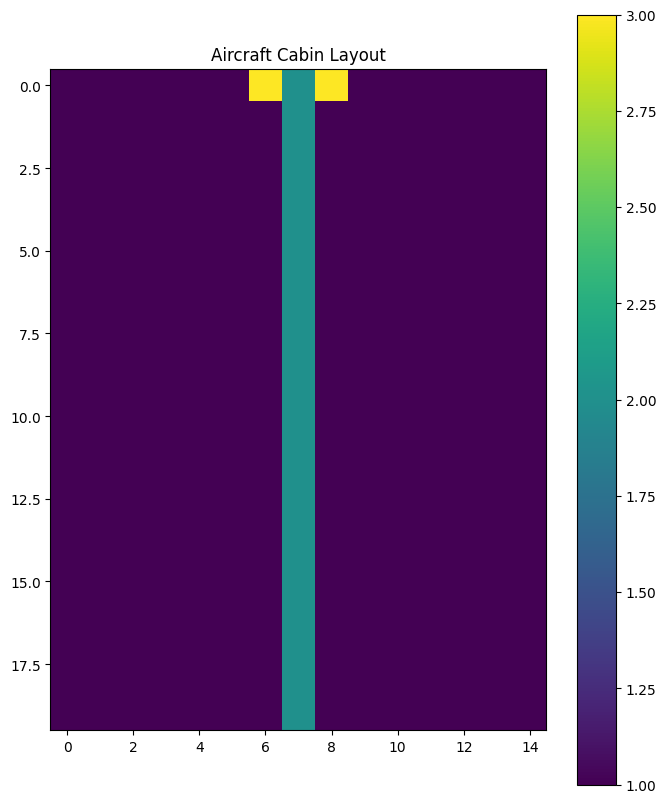

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Aircraft size
ROWS = 20
COLS = 15

# Create empty grid
grid = np.zeros((ROWS, COLS))

# Legend
# 0 = Empty
# 1 = Seat
# 2 = Aisle
# 3 = Exit

# Create seats
for r in range(ROWS):
    for c in range(COLS):

        # aisle columns
        if c == 7:
            grid[r][c] = 2

        # exits
        elif r == 0 and c in [6,7,8]:
            grid[r][c] = 3

        # seats
        else:
            grid[r][c] = 1

# Show grid
plt.figure(figsize=(8,10))
plt.imshow(grid, cmap='viridis')
plt.title("Aircraft Cabin Layout")
plt.colorbar()
plt.show()

In [2]:
passengers = []

for r in range(1, ROWS):
    for c in range(COLS):

        if grid[r][c] == 1:
            passengers.append((r, c))

print("Total Passengers:", len(passengers))

Total Passengers: 266


In [3]:
exits = [(0,6), (0,7), (0,8)]

def nearest_exit(position):

    pr, pc = position

    distances = []

    for ex in exits:
        er, ec = ex

        distance = abs(pr-er) + abs(pc-ec)

        distances.append((distance, ex))

    distances.sort()

    return distances[0][1]

In [4]:
def move_passenger(position):

    r, c = position

    exit_r, exit_c = nearest_exit(position)

    # Move upward
    if r > exit_r:
        r -= 1

    # Move left/right
    elif c < exit_c:
        c += 1

    elif c > exit_c:
        c -= 1

    return (r, c)

In [5]:
steps = 10

current_positions = passengers.copy()

for step in range(steps):

    new_positions = []

    for p in current_positions:

        new_p = move_passenger(p)

        new_positions.append(new_p)

    current_positions = new_positions

    print(f"Step {step+1} completed")

Step 1 completed
Step 2 completed
Step 3 completed
Step 4 completed
Step 5 completed
Step 6 completed
Step 7 completed
Step 8 completed
Step 9 completed
Step 10 completed


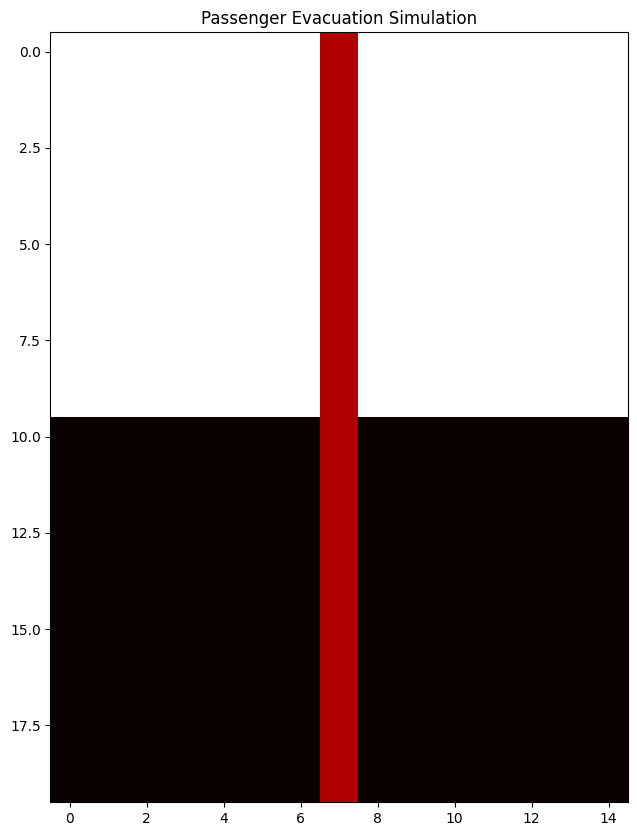

In [6]:
visual_grid = grid.copy()

for r, c in current_positions:
    visual_grid[r][c] = 5

plt.figure(figsize=(8,10))
plt.imshow(visual_grid, cmap='hot')
plt.title("Passenger Evacuation Simulation")
plt.show()

In [7]:

# 4 = Smoke

for r in range(10,15):
    for c in range(5,10):
        grid[r][c] = 4

In [8]:
# 6 = Fire

grid[12][7] = 6
grid[13][7] = 6

In [9]:
# Block one exit
grid[0][7] = 6

In [10]:
import networkx as nx

G = nx.grid_2d_graph(ROWS, COLS)

# Remove blocked cells
for r in range(ROWS):
    for c in range(COLS):

        if grid[r][c] in [4,6]:   # smoke/fire
            if (r,c) in G:
                G.remove_node((r,c))

In [11]:
start = (19, 5)
goal = (0, 6)

path = nx.astar_path(G, start, goal)

print("Path Found:")
print(path)

Path Found:
[(19, 5), (18, 5), (17, 5), (16, 5), (15, 5), (15, 4), (14, 4), (13, 4), (12, 4), (11, 4), (10, 4), (9, 4), (8, 4), (7, 4), (6, 4), (5, 4), (4, 4), (3, 4), (2, 4), (1, 4), (0, 4), (0, 5), (0, 6)]


In [12]:
path2 = nx.dijkstra_path(G, start, goal)

print("Dijkstra Path:")
print(path2)

Dijkstra Path:
[(19, 5), (18, 5), (17, 5), (16, 5), (15, 5), (15, 4), (14, 4), (13, 4), (12, 4), (11, 4), (10, 4), (9, 4), (8, 4), (7, 4), (6, 4), (5, 4), (4, 4), (3, 4), (2, 4), (1, 4), (0, 4), (0, 5), (0, 6)]


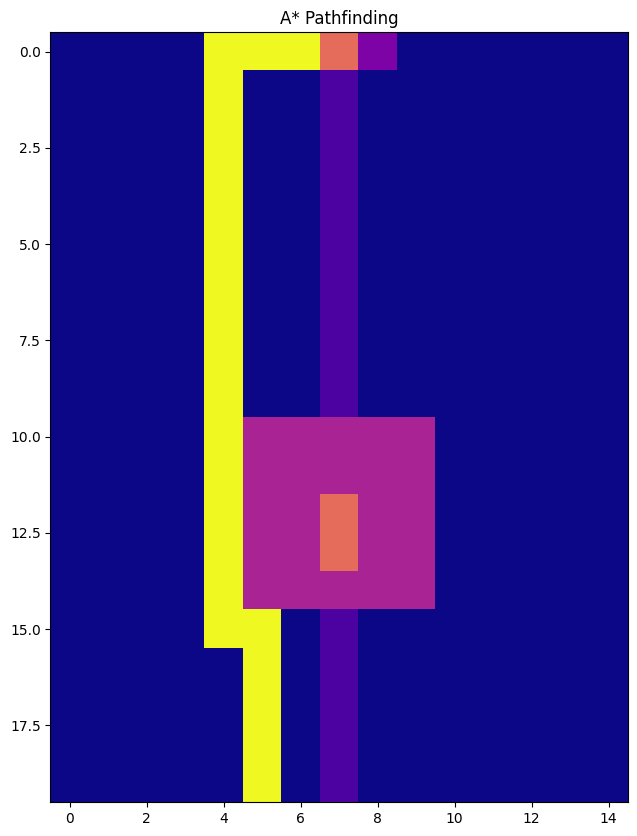

In [13]:
path_grid = grid.copy()

for r,c in path:
    path_grid[r][c] = 9

plt.figure(figsize=(8,10))
plt.imshow(path_grid, cmap='plasma')
plt.title("A* Pathfinding")
plt.show()

In [14]:
from collections import Counter

aisle_positions = []

for p in current_positions:

    r,c = p

    if c == 7:
        aisle_positions.append(r)

counter = Counter(aisle_positions)

print("Congestion Areas:")

for row, count in counter.items():

    if count > 3:
        print(f"Heavy congestion at row {row}")

Congestion Areas:


In [24]:
from mesa import Agent, Model

# -----------------------------------
# Passenger Agent
# -----------------------------------

class PassengerAgent(Agent):

    def __init__(self, unique_id, model):
        super().__init__(model)
        self.unique_id = unique_id

    def step(self):
        print(f"Passenger {self.unique_id} moving toward exit")


# -----------------------------------
# Evacuation Model
# -----------------------------------

class EvacuationModel(Model):

    def __init__(self, num_agents):

        super().__init__()

        self.num_agents = num_agents

        # Create agent list
        self.agents_list = []

        # Create passengers
        for i in range(self.num_agents):

            agent = PassengerAgent(i, self)

            self.agents_list.append(agent)

    # Run one simulation step
    def step(self):

        for agent in self.agents_list:
            agent.step()


# -----------------------------------
# Run Simulation
# -----------------------------------

model = EvacuationModel(5)

for i in range(3):

    print(f"\nSimulation Step {i+1}")

    model.step()


Simulation Step 1
Passenger 0 moving toward exit
Passenger 1 moving toward exit
Passenger 2 moving toward exit
Passenger 3 moving toward exit
Passenger 4 moving toward exit

Simulation Step 2
Passenger 0 moving toward exit
Passenger 1 moving toward exit
Passenger 2 moving toward exit
Passenger 3 moving toward exit
Passenger 4 moving toward exit

Simulation Step 3
Passenger 0 moving toward exit
Passenger 1 moving toward exit
Passenger 2 moving toward exit
Passenger 3 moving toward exit
Passenger 4 moving toward exit
